In [ ]:
# 这里命令行创建一个.env文件 ，主要是配置大模型的api

import os

# 1. 判断 .env 文件是否不存在
if not os.path.exists('.env'):
    # 2. 只有在不存在的时候，才执行 Bash 的 cp 命令
    # os.system 会在操作系统的终端里静默执行这句命令
    exit_code = os.system('cp .env.example .env')
    
    if exit_code == 0:
        print("💡 提示：已通过 bash 命令成功复制 .env.example 到 .env")
    else:
        print("❌ 复制失败，请检查 .env.example 是否存在或权限设置。")
else:
    print("✅ .env 文件已存在，跳过 bash 命令。")

✅ .env 文件已存在，跳过 bash 命令。


In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

In [2]:
_ = load_dotenv()

In [4]:
# 配置大模型服务
llm = ChatOpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    model="qwen3-coder-plus",
)

# 创建一个简单的Agent
agent = create_agent(
    model=llm,
    system_prompt="You are a helpful assistant",
)

# 运行Agent
response = agent.invoke({'messages': '你好'})

response['messages']

[HumanMessage(content='你好', additional_kwargs={}, response_metadata={}, id='858ae3a5-a6fa-4dfc-a5a7-eaca2dd57354'),
 AIMessage(content='你好呀！✨ 很高兴见到你！今天过得怎么样？希望你度过了愉快的一天。我随时准备好陪你聊天、帮你解决问题，或者就这样轻松愉快地闲聊一会儿。有什么想跟我分享的吗？ 🌟', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 19, 'total_tokens': 69, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'qwen3-coder-plus', 'system_fingerprint': None, 'id': 'chatcmpl-72913433-b80a-9153-b76e-a46c0c52979e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d99fc-92a2-7f30-9454-40cae9bca09b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 50, 'total_tokens': 69, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}})]

# 调用带工具的Agent

In [5]:
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

# 创建带工具调用的Agent
tool_agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)

# 运行Agent
response = tool_agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
)

response['messages']

[HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='031292fe-e4f9-4609-b56e-6ef2446affd7'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 270, 'total_tokens': 291, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'qwen3-coder-plus', 'system_fingerprint': None, 'id': 'chatcmpl-74c18a37-7c0b-9530-91f0-f827ddef808d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d9a00-466c-7060-8100-c8911f2c2025-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'sf'}, 'id': 'call_010e8d5986dd4b1cbceb043a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 270, 'output_tokens': 21, 'total_tokens': 291, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}),
 ToolMessage(content="It's always sunny in sf!", 

上述你可以发现这里调用两次LLM

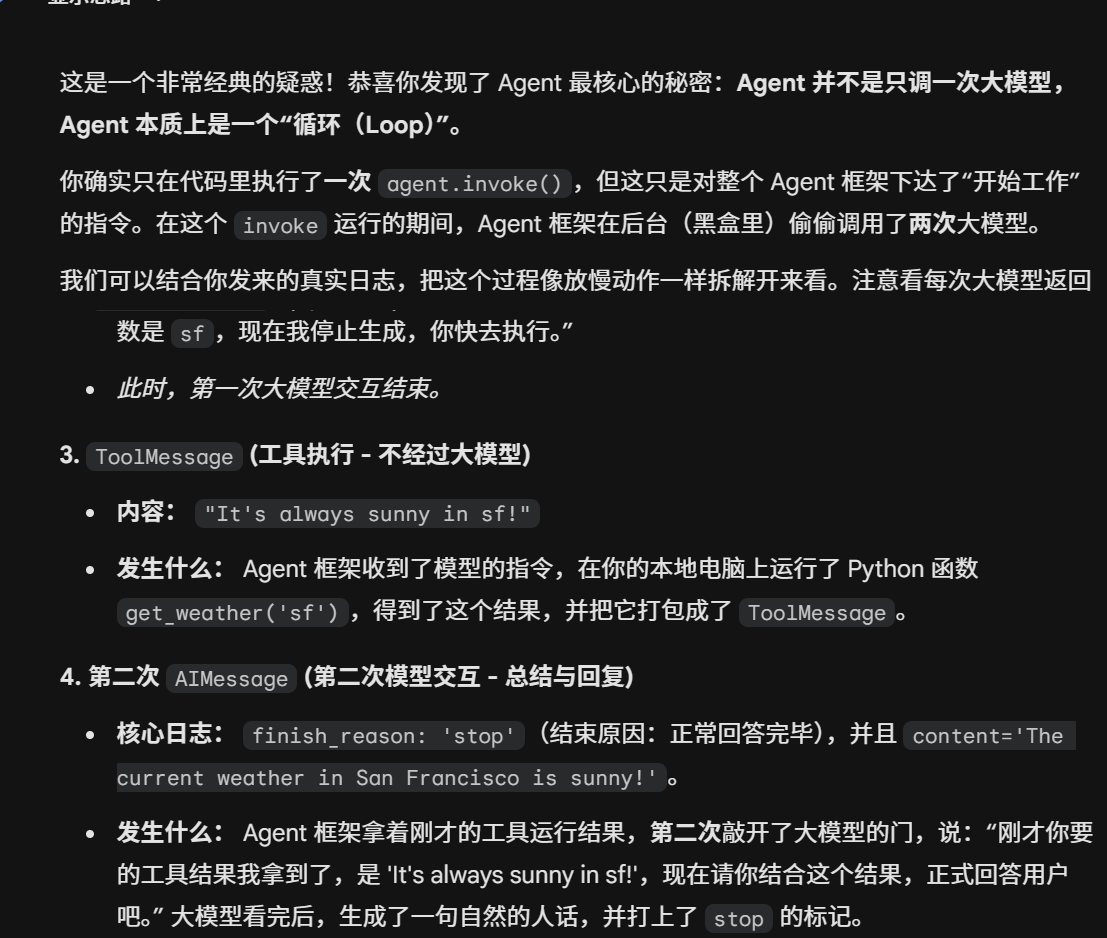

# 使用ToolRunTime控制工具权限

invoke调用的关键步骤是：

调用Agent, 这里 message中的user用来让大模型能够区分这个是由谁提问的，content是对大模型提出的问题， 
1. 大模型接收到这句话后并且收到Agent的tool时候就决定调用add math 这个方法，并且把a = 8234783和b = 94123832时
2. Agent调用这个add math方法，把context（大模型并不知道）， a ， b 放入到add math中具体执行，然后把结果返回给大模型
3. 大模型根据这些结果再返回具体的回答（包装成人话）

In [7]:
from typing import Literal, Any
from pydantic import BaseModel
from langchain.tools import tool, ToolRuntime

# 这里继承了pydantic库来定义一个数据类型，即只能有两种身份："admin", "user"
class Context(BaseModel):
    authority: Literal["admin", "user"]

# 创建工具，这个工具是给Agent执行的，当加入了@tool的时候，Langchain会扫描所有东西，其中ToolRuntime会被剔除不写入工具说明书中
# {
#   "name": "add_math",
#   "description": "Add two numbers together.",
#   "parameters": {
#     "type": "object",
#     "properties": {
#       "a": {"type": "integer"},
#       "b": {"type": "integer"}
#     },
#     "required": ["a", "b"]
#   }
# }
@tool 
def add_math(runtime:ToolRuntime[Context, Any], a:int, b:int)->int:
    """计算并返回两个数字相加的结果。"""
    
    authority = runtime.context.authority
    if authority != "admin":
        raise PermissionError("User does not have permission to add numbers")
    return a+b

# 创建能够调用tool的Agent
tool_agent = create_agent(
    model=llm,
    tools=[get_weather, add_math],
    system_prompt="You are a helpful assistant", 
)

# 调用Agent, 这里 message中的user用来让大模型能够区分这个是由谁提问的，content是对大模型提出的问题， 
# 1. 大模型接收到这句话后（prompt）并且工具说明书（tool_agent 中定义的tools）时候就决定调用add math 这个方法，并且返回{"name": "add_math", "kwargs": {"a": 8234783, "b": 94123832}}
# 2. Agent调用这个add math方法，把context（大模型并不知道）， a ， b 放入到add math中具体执行，然后把结果返回给大模型
# 3. 大模型根据这些结果再返回具体的回答（包装成人话）
response = tool_agent.invoke(
    {"messages" : [
        {"role":"user", "content":"请计算 8234783 + 94123832 = ?"}
    ]},
    config={"configurable":{"thread_id" : "1"}},
    context=Context(authority="admin") # 这里context是放在agent里面的，不提交到LLM
)

In [8]:
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

请计算 8234783 + 94123832 = ?
================================== Ai Message ==================================
Tool Calls:
  add_math (call_06838d9a15184827978ad26b)
 Call ID: call_06838d9a15184827978ad26b
  Args:
    a: 8234783
    b: 94123832
================================= Tool Message =================================
Name: add_math

102358615
================================== Ai Message ==================================

8234783 + 94123832 = 102358615。


# 结构化输出 


In [ ]:
from pydantic import BaseModel, Field

class CalcInfo(BaseModel):
    output: int = Field(description="The calculation result") # 这里声明了一个int类型的数据，并且添加了备注：The calculation result

In [10]:
# 创建带结构化输出的Agent
structured_agent = create_agent(
    model=llm,
    tools=[get_weather, add_math],
    system_prompt="You are a helpful assistant",
    response_format=CalcInfo, # 指定结构化输出的样子 
)

response = structured_agent.invoke(
    {"messages": [{"role": "user", "content": "请计算 8234783 + 94123832 = ?"}]},
    config={"configurable": {"thread_id": "1"}},
    context=Context(authority="admin"),
)

In [11]:
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

请计算 8234783 + 94123832 = ?
================================== Ai Message ==================================
Tool Calls:
  add_math (call_26fad39f4f564d20a403ecf8)
 Call ID: call_26fad39f4f564d20a403ecf8
  Args:
    a: 8234783
    b: 94123832
================================= Tool Message =================================
Name: add_math

102358615
================================== Ai Message ==================================
Tool Calls:
  CalcInfo (call_a15f21b1790d4a3bb15e417c)
 Call ID: call_a15f21b1790d4a3bb15e417c
  Args:
    output: 102358615
================================= Tool Message =================================
Name: CalcInfo

Returning structured response: output=102358615


In [12]:
response['messages']

[HumanMessage(content='请计算 8234783 + 94123832 = ?', additional_kwargs={}, response_metadata={}, id='5d790c12-66c6-4fdc-b203-c727972f250e'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 435, 'total_tokens': 474, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'qwen3-coder-plus', 'system_fingerprint': None, 'id': 'chatcmpl-84f35e7c-4be4-932a-a78d-539addd39ed5', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d9a3c-a135-7c83-a7c1-b38192e6ddf9-0', tool_calls=[{'name': 'add_math', 'args': {'a': 8234783, 'b': 94123832}, 'id': 'call_26fad39f4f564d20a403ecf8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 435, 'output_tokens': 39, 'total_tokens': 474, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}),
 ToolMessage(content='102358615', na

# 流式输出 

In [13]:
agent = create_agent(
    model=llm,
    tools = [get_weather]
)

for chunk in agent.stream(
    {"messages":[
        {"role":"user", "content": "What is the weather in SF?"}
    ]
     },
    stream_mode="updates"
):
    for step, data in chunk.items():
        print(f"step: {step}")
        print(f"content: {data['messages'][-1].content_blocks}")

step: model
content: [{'type': 'tool_call', 'name': 'get_weather', 'args': {'city': 'SF'}, 'id': 'call_bb8109f58234403c973882bd'}]
step: tools
content: [{'type': 'text', 'text': "It's always sunny in SF!"}]
step: model
content: [{'type': 'text', 'text': "It seems like there might be some confusion. While San Francisco (SF) is known for its microclimates and can have varying weather, it's not always sunny. The weather can range from foggy and cool to partly cloudy or even rainy, depending on the season and time of day. For accurate and up-to-date weather information, checking a reliable weather service is recommended!"}]
